# Extended Data Figure 2 — classes of mutations detected in pre-AML and control samples

This notebook reproduces **Extended Data Figure 2** in which each column is one
pre-AML case or control and coloured boxes mark the mutation classes detected. The bottom panel summarises additional
clinical / exposure data per individual — other haematological malignancy (MDS, CMML, MPN,
lymphoma, myeloma), non-haematological cancer, pre-AML chemotherapy, and smoking history
(pack-year categories by colour). Cases and controls are drawn as separate panels.

## Data availability
Sample age and timepoint information is not needed for this figure, so the data files used are those that do not contain this information.
Data files with unrounded ages and sample timings are available under controlled access, deposited in the European Genome-phenome Archive (EGA) and released to approved researchers via a Data Access Committee administered by the corresponding authors.  However these are not required in order to reproduce Extended Data Figure 2.

| file | used for | location 
|---|---|---|
| `UKCTOCS_samples_processed_minimal_information.csv` | case / control sample lists | Data_files |
| `UKCTOCS_non-germline_variants_calls_SNVs_indels_mCAs_rounded_ages.csv` | somatic variant calls | Data_files |
| `UKCTOCS_participant_clinical_characteristics_rounded.csv` | clinical / exposure bottom panel | Data_files |
| `All_fitness_establishment_times_with_sd_and_CI.csv` | contains info on which samples carry an inferred "missing driver" (produced by the `Supplementary_Fig_46.ipynb` notebook; it is also Supplementary Table 9) | Data_files |


## 1. Imports

In [26]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
%matplotlib inline

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Helvetica'

c1 = (1.00, 0.18, 0.33)   # NPM1 red

## 2. Colours and gene classes

In [27]:
#define the colors from colorbrewer2
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'

In [28]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
yellow = '#ffffd4'

In [29]:
mutation_class_colors = {'NPM1': c1,
                        'DNA methylation': blue3,
                        'Chromatin modifiers': orange3,
                        'Transcription factors':  green3,
                        'Transcriptional corepressors':  green4,
                        'Tumour suppressor': purple3,
                        'Spliceosome': 'palevioletred',
                        'Cohesin': 'lightseagreen',
                        'Cell signalling': red2,
                        'mCA': grey4,
                         'missing driver': grey4}

In [30]:
mutation_classes = {'NPM1': 'NPM1',
                   'DNMT3A': 'DNA methylation',
                   'TET2': 'DNA methylation',
                   'IDH1': 'DNA methylation',
                   'IDH2': 'DNA methylation',
                   'ASXL1': 'Chromatin modifiers',
                   'EZH2': 'Chromatin modifiers',
                   'RUNX1': 'Transcription factors',
                   'CEBPA': 'Transcription factors',
                   'GATA2': 'Transcription factors',
                   'BCOR': 'Transcriptional corepressors',
                   'BCORL1': 'Transcriptional corepressors',
                   'TP53': 'Tumour suppressor',
                   'PPM1D': 'Tumour suppressor',
                   'CHEK2': 'Tumour suppressor',
                   'WT1': 'Tumour suppressor',
                   'CBL': 'Tumour suppressor',
                   'DDX41': 'Tumour suppressor',
                   'SRSF2': 'Spliceosome',
                   'SF3B1': 'Spliceosome',
                   'U2AF1': 'Spliceosome',
                   'ZRSR2': 'Spliceosome',
                   'RAD21': 'Cohesin',
                   'STAG2': 'Cohesin',
                   'FLT3': 'Cell signalling',
                   'KIT': 'Cell signalling',
                   'JAK2': 'Cell signalling',
                   'KRAS': 'Cell signalling',
                   'NRAS': 'Cell signalling',
                   'PTPN11': 'Cell signalling',
                   'CSF3R': 'Cell signalling',
                   'GNB1': 'Cell signalling',
                   'GNAS': 'Cell signalling',
                   'MPL': 'Cell signalling',
                    'mCA': 'mCA',
                   'missing driver': 'missing driver'}

In [31]:
panel_list = ['NPM1','DNMT3A', 'TET2', 'IDH2', 'IDH1', 'ASXL1', 'EZH2', 'RUNX1', 'CEBPA', 'GATA2', 'BCORL1', 'BCOR', 'TP53', 'CHEK2',  'CBL', 'WT1','PPM1D', 'DDX41',
             'SRSF2', 'SF3B1', 'ZRSR2', 'U2AF1', 'STAG2', 'RAD21', 'MPL', 'GNB1', 'GNAS', 'JAK2', 'CSF3R', 'KRAS', 'NRAS', 'FLT3', 'KIT', 'PTPN11', 'mCA', 'missing driver']
    
panel_list.append('no mutations')

panel_list_dict = {}
for i in enumerate(reversed(panel_list)):
    panel_list_dict[i[1]]=i[0]

## 3. Build data and plot (see Data availability above)

## Create dictionaries of sample details

In [32]:
CSV = "Data_files/UKCTOCS_samples_processed_minimal_information.csv"

df_samples = pd.read_csv(CSV, encoding="cp1252")
participant = df_samples["SAMPLE ID"].str.rsplit("_s", n=1).str[0]

grouped = df_samples.groupby([df_samples["GROUP"], participant])["SAMPLE ID"].apply(list)

cases = grouped["Case"].to_dict()
controls = grouped["Control"].to_dict()

In [33]:
CSV = "Data_files/UKCTOCS_participant_clinical_characteristics_rounded.csv"

COLS = {
    "Other haematological malignancy \n(timing relative to AML diagnosis)": "haem_malignancy",
    "Other cancer diagnosis \n(timing relative to AML diagnosis; treatment)": "other_cancer",
    "Timing of any chemotherapy pre-AML diagnosis (indication)": "chemotherapy",
    "Smoking (pack years)": "pack_years",
}

df_other_history = pd.read_csv(CSV, encoding="cp1252").rename(columns=COLS)

MDS, MPN, CMML, myeloma, lymphoma = [], [], [], [], []
cancer, chemo, smoking_unknown, chemo_unknown = [], [], [], []
smoking_dict = {}

for _, row in df_other_history.iterrows():
    sample_id = row["Sample ID"]

    # --- Other haematological diagnoses (any timing) ---
    diagnosis = row["haem_malignancy"]
    if pd.notna(diagnosis):
        if "MDS" in diagnosis:
            MDS.append(sample_id)
        if any(k in diagnosis for k in ("MPN", "ET", "MF", "CML")):
            MPN.append(sample_id)
        if "CMML" in diagnosis:
            CMML.append(sample_id)
        if "Myeloma" in diagnosis:
            myeloma.append(sample_id)
        if "DLBCL" in diagnosis or "NHL" in diagnosis or "lymphoma" in diagnosis.lower():
            lymphoma.append(sample_id)

    # --- Non-haematological cancer ---
    cancer_hx = row["other_cancer"]
    if pd.notna(cancer_hx):
        cancer.append(sample_id)
        if "unknown" in str(cancer_hx).lower():   # unknown whether treated with chemo
            chemo_unknown.append(sample_id)

    # --- Chemotherapy (column is pre-AML by definition, so presence is enough) ---
    if pd.notna(row["chemotherapy"]):
        chemo.append(sample_id)

    # --- Smoking ---
    smoking_hx = row["pack_years"]
    if pd.isna(smoking_hx):
        continue
    if str(smoking_hx).strip() == "Unknown":
        smoking_unknown.append(sample_id)
    elif float(smoking_hx) > 0:
        smoking_dict[sample_id] = float(smoking_hx)

# One row can match two MPN keywords (C92_022: 'MPN ..., MF ...'), so dedupe.
MDS, MPN, CMML, myeloma, lymphoma, cancer, chemo, chemo_unknown, smoking_unknown = (
    list(dict.fromkeys(lst)) for lst in
    (MDS, MPN, CMML, myeloma, lymphoma, cancer, chemo, chemo_unknown, smoking_unknown)
)

# Import the sample variant details

In [34]:
#dataframe of variant trajectories
df = pd.read_csv("Data_files/UKCTOCS_non-germline_variants_calls_SNVs_indels_mCAs_rounded_ages.csv")

In [35]:
def sample_trajectories(person_ID, df): #extract trajectories of each variant for a given sample, e.g. 'C92_002'

    filtered_df = df[df['sample name'].str.startswith(person_ID)]

#     person_variant_dict={}
    var_dict={}
    variant_details = {}
#     person_variant_dict[person_ID]=var_dict

    gene_variant = ''

    for index, row in filtered_df.iterrows():
        # Access data for each column by column name
        variant_type=row['variant_type']
#         if row['VAF (cell fraction for mCAs)'] != 'not processed':
        if variant_type=='SNV':
            variant=row['AA_change']
            gene=row['gene']
            VAF=float(row['VAF (cell fraction for mCAs)'])
            age=row['age_sample_taken']
            gene_variant=gene+'_'+variant
        elif (variant_type=='CNLOH' or variant_type=='GAIN' or variant_type=='LOSS'):
            VAF=row['VAF (cell fraction for mCAs)']
            age=row['age_sample_taken']
            chromosome=row['chromosome']
            gene_variant=chromosome+'_'+variant_type
        elif (variant_type=='Deletion' or variant_type=='Insertion' or variant_type=='Complex'):
            VAF=float(row['VAF (cell fraction for mCAs)'])
            variant=row['AA_change']
            age=row['age_sample_taken']
            gene=row['gene']
            gene_variant=gene+'_'+variant
        elif (variant_type=='ITD'):
            VAF=float(row['VAF (cell fraction for mCAs)'])
            variant=row['AA_change']
            age=row['age_sample_taken']
            gene=row['gene']
            gene_variant=gene+'_'+variant
            
        if gene_variant in var_dict.keys():
            if VAF != 'not processed':
                var_dict[gene_variant][age]=float(VAF)
        else:
            if VAF != 'not processed':
                var_dict[gene_variant]={age: float(VAF)}
            
        if gene_variant != '':
            if variant_type not in ('CNLOH', 'GAIN', 'LOSS'):
                chromosome = row['chromosome']
                start = int(row['start'])
                ref = row['REF']
                variant_details[gene_variant]=(chromosome, start, ref)
            else:
                variant_details[gene_variant]=(chromosome, '', '')

    return var_dict, variant_details

In [36]:
case_trajectories = {}
for sample in cases:
    var_dict, variant_details = sample_trajectories(sample, df)
    case_trajectories[sample] = var_dict
    
# case_trajectories

In [37]:
control_trajectories = {}
for sample in controls:
    control_var_dict, control_variant_details = sample_trajectories(sample, df)
    control_trajectories[sample] = control_var_dict
    
# control_trajectories

# Import which samples have missing drivers

In [38]:
MISSING = {'X', 'Y', 'Z'}
df = pd.read_csv('Data_files/All_fitness_establishment_times_with_sd_and_CI.csv') #written by the Supplementary_Fig_46 notebook
df['Sample name'] = df['Sample_name']
samples_with_missing_drivers = (
    df.assign(driver=df['Clone'].str.split(','))
      .explode('driver')
      .assign(driver=lambda d: d['driver'].str.strip())
      .query('driver in @MISSING')
      .groupby('Sample name')['driver']
      .nunique()
      .to_dict()
)
# samples_with_missing_drivers

# Which samples have which evolution pattern

In [39]:
case_linear_evolution = ['C92_002', 
                    'C92_003',
                    'C92_005',
                    'C92_007',
                    'C92_011',
                    'C92_018',
                    'C92_019',
                    'C92_024',
                    'C92_032',
                    'C92_033',
                    'C92_034',
                    'C92_041',
                    'C92_042',
                    'C92_049',
                    'C92_053',
                    'C92_054',
                    'C92_057',
                    'C92_058',
                    'C92_061',
                    'C92_062',
                    'C92_064',
                    'C92_065',
                    'C92_067',
                    'C92_068',
                    'C92_070',
                    'C92_086']

case_clonal_interference = ['C92_008',
                       'C92_009',
                       'C92_012',
                       'C92_022',
                       'C92_023',
                       'C92_036',
                       'C92_045',
                       'C92_050',
                       'C92_056',
                       'C92_066',
                       'C92_090']

case_late_evolution = ['C92_015',
                  'C92_043',
                  'C92_044',
                  'C92_047',
                  'C92_048',
                  'C92_052',
                  'C92_055',
                  'C92_063',
                  'C92_072',
                  'C92_016'] #Linear/late

case_evolutionary_patterns_dict = {'Linear': [], 'Clonal interference': [], 'Late': []}

for sample in case_linear_evolution:
    case_evolutionary_patterns_dict['Linear'].append(sample)

for sample in case_clonal_interference:
    case_evolutionary_patterns_dict['Clonal interference'].append(sample)

for sample in case_late_evolution:
    case_evolutionary_patterns_dict['Late'].append(sample)

In [40]:
control_linear_evolution = ['CNTRL_001', 
                    'CNTRL_002', 
                    'CNTRL_004', 
                    'CNTRL_160', 
                    'CNTRL_163', 
                    'CNTRL_164', 
                    'CNTRL_166', 
                    'CNTRL_167', 
                    'CNTRL_168', 
                    'CNTRL_169', 
                    'CNTRL_172', 
                    'CNTRL_173', 
                    'CNTRL_175', 
                    'CNTRL_179', 
                    'CNTRL_180', 
                    'CNTRL_182', 
                    'CNTRL_184',
                    'CNTRL_185',
                    'CNTRL_186', 
                    'CNTRL_187', 
                    'CNTRL_190', 
                    'CNTRL_191', 
                    'CNTRL_193', 
                    'CNTRL_194', 
                    'CNTRL_195', 
                    'CNTRL_196', 
                    'CNTRL_197', 
                    'CNTRL_199', 
                    'CNTRL_202', 
                    'CNTRL_204']

control_clonal_interference = ['CNTRL_005','CNTRL_162','CNTRL_192']

control_late_evolution = ['CNTRL_203']

control_evolutionary_patterns_dict = {'Linear': [], 'Clonal interference': [], 'Late': []}

for sample in control_linear_evolution:
    control_evolutionary_patterns_dict['Linear'].append(sample)

for sample in control_clonal_interference:
    control_evolutionary_patterns_dict['Clonal interference'].append(sample)

for sample in control_late_evolution:
    control_evolutionary_patterns_dict['Late'].append(sample)

# Count the number of each gene for each sample

In [41]:
def gene_mutation_incidence(trajectories):
    #count the incidence of numbers of each gene
    all_samples_gene_list = {}
    all_samples_variants = {}
    all_samples_gene_counts = {}

    for k, v in trajectories.items():
        sample_genes = []
        sample_variants = []
        sample_genes_counts = {}
        for variant, trajectory in v.items():
            variant2 = variant.split('_')
            if 'chr' in variant2[0]:
                gene = 'mCA'
#             elif variant2[0] in ['X', 'Y', 'Z']:
#                 gene = 'missing driver'
            else:
                gene = variant2[0]

            if gene not in sample_genes:
                sample_genes.append(gene)
            if variant not in sample_variants:
                sample_variants.append(variant)

            if gene in sample_genes_counts.keys():
                sample_genes_counts[gene]+=1
            else:
                sample_genes_counts[gene]=1

        if k in samples_with_missing_drivers.keys():
            number_of_missing_drivers = samples_with_missing_drivers[k]
            sample_genes.append('missing driver')
            sample_variants.extend([f'missing driver {i+1}' for i in range(number_of_missing_drivers)])
            sample_genes_counts['missing driver'] = number_of_missing_drivers

        all_samples_gene_list[k]=sample_genes
        all_samples_variants[k]= sample_variants
        all_samples_gene_counts[k]=sample_genes_counts

    return all_samples_gene_list, all_samples_variants, all_samples_gene_counts

In [42]:
def evolutionary_patterns_genes_mutations(all_samples_gene_list, all_samples_variants, evolutionary_patterns_dict): 
    evolutionary_patterns_dict_sorted_by_number_genes = {}
    evolutionary_patterns_dict_sorted_by_number_mutations = {}

    for k, v in evolutionary_patterns_dict.items():
        evol_pattern = k
        samples = v
        samples_lists = []
        for sample in samples:
            if sample not in all_samples_gene_list:   # dropped from the final cohort
                continue
            number_mutated_genes = len(all_samples_gene_list[sample])
            number_mutations = len(all_samples_variants[sample])
            samples_lists.append((sample, number_mutated_genes, number_mutations))

        sorted_samples_list_by_genes = sorted(samples_lists, key=lambda x: x[1], reverse = True)  #sort on the number of mutated genes
        sorted_samples_list_by_mutations = sorted(samples_lists, key=lambda x: x[2], reverse = True) #sort on the number of mutations e.g. if more than one mutation in a gene

        evolutionary_patterns_dict_sorted_by_number_genes[k]=sorted_samples_list_by_genes
        evolutionary_patterns_dict_sorted_by_number_mutations[k]=sorted_samples_list_by_mutations
        
    return evolutionary_patterns_dict_sorted_by_number_genes, evolutionary_patterns_dict_sorted_by_number_mutations

# Plot the figure

## Cases

In [43]:
cases_gene_list, cases_variants, cases_gene_counts = gene_mutation_incidence(case_trajectories)

In [44]:
cases_evol_patterns_sorted_genes, cases_evol_patterns_sorted_mutations = evolutionary_patterns_genes_mutations(cases_gene_list, cases_variants, case_evolutionary_patterns_dict)

In [45]:
for case in cases:
    case_with_mutations = 0
    for evol_pattern, sample_list in cases_evol_patterns_sorted_mutations.items():
        for sample in sample_list:
            if sample[0]==case:
                case_with_mutations+=1
    # if case_with_mutations ==0:
    #     cases_evol_patterns_sorted_mutations['Late'].append((case, 0, 0))
    #     cases_evol_patterns_sorted_genes['Late'].append((case, 0, 0))

    if case_with_mutations == 0:
        n_genes = len(cases_gene_list.get(case, []))
        n_muts  = len(cases_variants.get(case, []))
        cases_evol_patterns_sorted_genes['Late'].append((case, n_genes, n_muts))
        cases_evol_patterns_sorted_mutations['Late'].append((case, n_genes, n_muts))

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


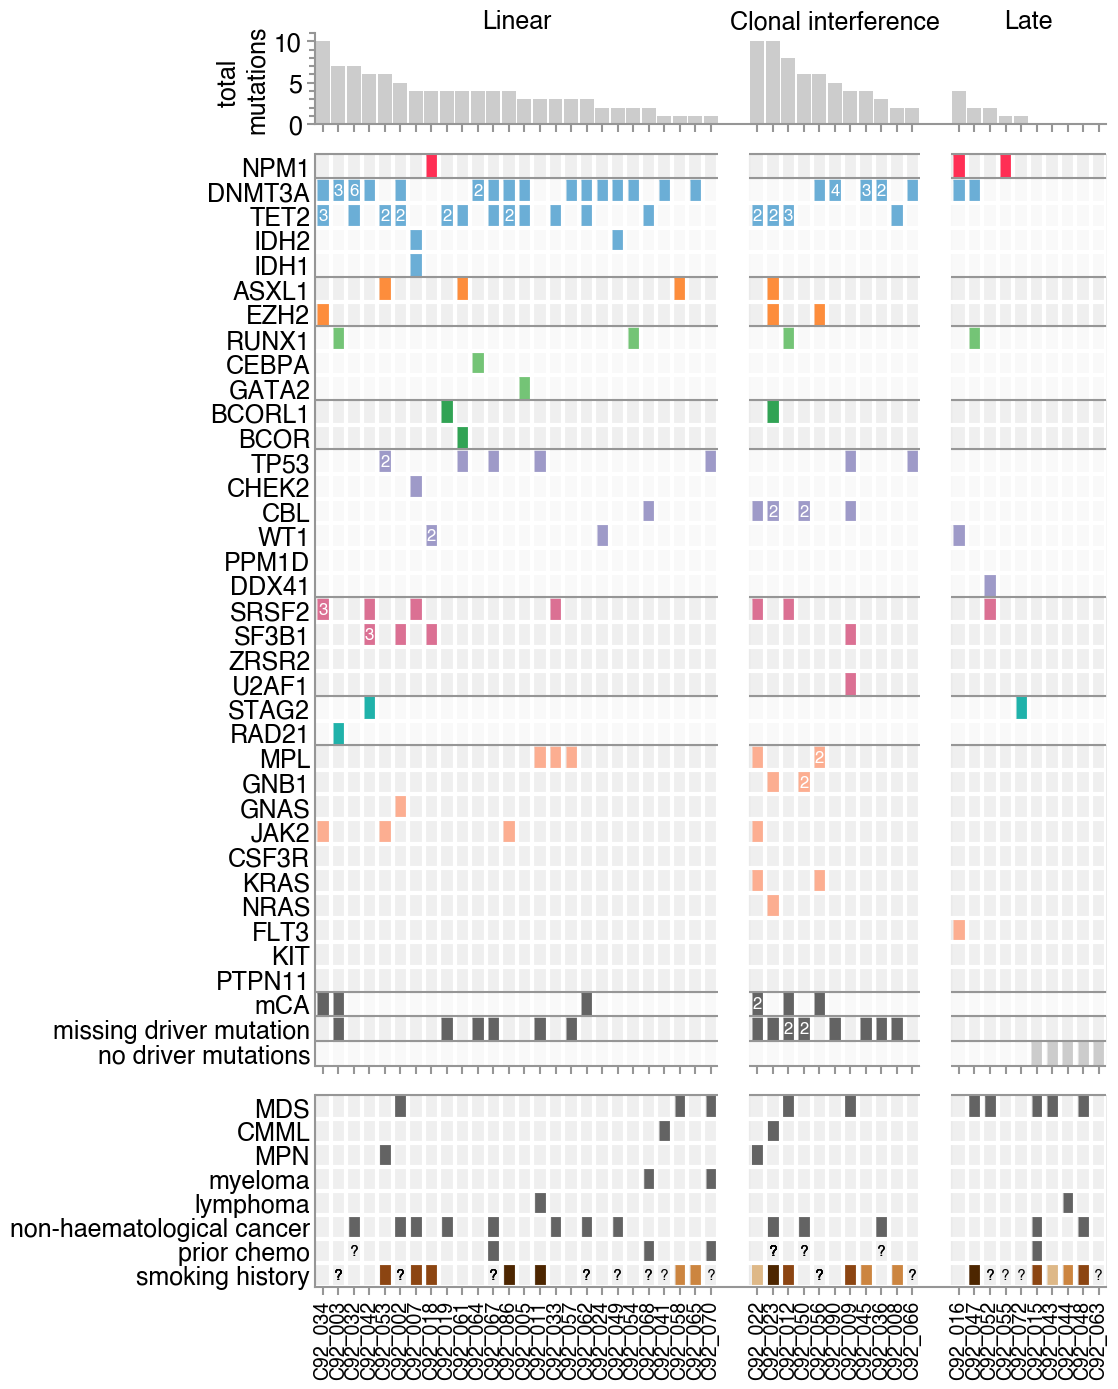

In [ ]:
#plot the figure - cases
# --- layout: numeric x positions with a gap between evolution categories -------
GAP = 2                      # blank slots between categories (same in both panels)
xpos, group_spans, _p = {}, {}, 0
for _evol, _slist in cases_evol_patterns_sorted_mutations.items():
    _start = _p
    for _sn in _slist:
        xpos[_sn[0]] = _p; _p += 1
    if _p > _start:
        group_spans[_evol] = (_start, _p - 1)
    _p += GAP
XMIN, XMAX = -0.5, (max(xpos.values()) + 0.5 if xpos else 0.5)
# -------------------------------------------------------------------------------

COL_IN = 0.173               # inches per sample column - identical in both panels
YLAB_IN = 2.45               # room for the gene labels on the left
fig, axes = plt.subplots(3, 1, figsize = (YLAB_IN + (XMAX - XMIN) * COL_IN, 14), sharex = True, gridspec_kw={'height_ratios': [1, 10, 2.1]})
plt.subplots_adjust(hspace=0.1)


ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]

helvetica_6 = 18
sample_id_fontsize = 14      # sample IDs on the x axis
qmark_fontsize = 11          # "?" markers for unknown history
axis_lw = 1.5                # same weight as the ax0 (histogram) spines

x = []
y = []
colors = []
annotation = []

x_bar = []
y_bar = []
c_bar = []

n = 0
for evol_type, samples_list in cases_evol_patterns_sorted_mutations.items():
#     print(evol_type)
    for sample_numbers in samples_list:
#         print(sample_numbers)
        n+=1
        sample = sample_numbers[0]
        number_genes_mutated = sample_numbers[1]
        number_mutations = sample_numbers[2]
        
        if sample in cases_gene_list.keys():
            sample_genes = cases_gene_list[sample]
        else:
            sample_genes = []
            
        if len(sample_genes)>0: #if the sample has a mutation
            for gene_mutated in sample_genes:
                mutation_ID = panel_list_dict[gene_mutated] #number assigned to the mutation (i.e. its y axis location)
                mutation_class = mutation_classes[gene_mutated]
                mutation_color = mutation_class_colors[mutation_class]
                x.append(sample)
                y.append(mutation_ID)
                colors.append(mutation_color)
                number_of_variants_in_gene = cases_gene_counts[sample][gene_mutated]
                annotation.append(number_of_variants_in_gene)
                

        else: #if the sample doesn't have any mutations
            x.append(sample)
            y.append(panel_list_dict['no mutations'])
            colors.append(grey2)
            annotation.append(0)

        x_bar.append(sample)
        y_bar.append(number_mutations)
        c_bar.append(grey2)
        
#         print(n)
            
ax0.bar([xpos[s] for s in x_bar], y_bar, width = 0.9, color = c_bar) #histogram at top of plot
            
verts = list(zip([-2,2,2,-2],[-4,-4,4,4])) #rectangle to plot for each mutation
            
ax1.scatter([xpos[s] for s in x], y, marker = verts, s = 250, color = colors)

for sample, gene, number_variants in zip(x, y, annotation):
    if number_variants>1:
        ax1.annotate(str(number_variants), xy = (xpos[sample], gene), ha = 'center', va = 'center', color = 'white', weight='bold', fontsize = 12)
        
        

# Plot other history

# Define 4 brown shades (lightest to darkest)
brown_shades = [(0.87, 0.72, 0.53), (0.80, 0.52, 0.25), (0.55, 0.27, 0.07), (0.30, 0.15, 0.00)]

# Bin pack-years into categories
def get_brown_shade(py):
    if py < 20:
        return brown_shades[0]
    elif py < 100:
        return brown_shades[1]
    elif py < 300:
        return brown_shades[2]
    else:
        return brown_shades[3]

for i in x:
    if i in MDS:
        ax2.scatter(xpos[i], 7, marker = verts, s = 250, color = grey4)
    if i in CMML:
        ax2.scatter(xpos[i], 6, marker = verts, s = 250, color = grey4)
    if i in MPN:
        ax2.scatter(xpos[i], 5, marker = verts, s = 250, color = grey4)
    if i in myeloma:
        ax2.scatter(xpos[i], 4, marker = verts, s = 250, color = grey4)
    if i in lymphoma:
        ax2.scatter(xpos[i], 3, marker = verts, s = 250, color = grey4)
    if i in cancer:
        ax2.scatter(xpos[i], 2, marker = verts, s = 250, color = grey4)
    if i in chemo:
        ax2.scatter(xpos[i], 1, marker = verts, s = 250, color = grey4)
    if i in smoking_dict.keys():
        ax2.scatter(xpos[i], 0, marker = verts, s = 250, color = get_brown_shade(smoking_dict[i]))
    if i in chemo_unknown:   # unknown whether cancer treated with chemo
        ax2.text(xpos[i], 1, '?', ha = 'center', va = 'center', fontsize = qmark_fontsize, color = 'black', weight = 'bold', zorder = 100)
    if i in smoking_unknown:   # unknown smoking history
        ax2.text(xpos[i], 0, '?', ha = 'center', va = 'center', fontsize = qmark_fontsize, color = 'black', weight = 'bold', zorder = 100)

# Configure plot        

ax0.set_ylim(0, 11)
ax0.yaxis.set_major_locator(MultipleLocator(5))
ax0.yaxis.set_minor_locator(MultipleLocator(1))
ax0.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax0.set_ylabel('total \nmutations', fontsize = helvetica_6)
ax0.tick_params(axis = 'both', which='major', length=6, width=1.5, color = '#969696')
ax0.tick_params(axis = 'both', which='minor', length=4, width=1.5, color = '#969696')

ax1.set_yticks(list(panel_list_dict.values())) #number assigned to each gene (for y axis)
# display names for the two special rows (internal keys are left unchanged)
_ylabels = ['missing driver mutation' if _g == 'missing driver'
            else 'no driver mutations' if _g == 'no mutations'
            else _g for _g in panel_list_dict.keys()]
ax1.set_yticklabels(_ylabels) #name of the gene

ax1.set_xlim(XMIN, XMAX)
ax1.set_ylim(-0.5, len(panel_list_dict)-0.5)
ax1.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax1.tick_params(axis = 'x', which='major', length=6, width=1.5, color = '#969696')
ax1.tick_params(axis = 'x', which='minor', length=4, width=1.5, color = '#969696')
ax2.set_xlim(XMIN, XMAX)
ax2.set_ylim(-0.5, 7.5)
ax2.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax2.tick_params(axis = 'x', which='major', length=6, width=1.5, color = '#969696', labelcolor='black')
ax2.tick_params(axis = 'x', which='minor', length=4, width=1.5, color = '#969696')


for axis in ['top','right']:
    ax0.spines[axis].set_visible(False)  
    
for axis in ['bottom','left']:
    ax0.spines[axis].set_linewidth(1.5)
    ax0.spines[axis].set_color('#969696')

for axis in ['bottom', 'top', 'right']:
    ax1.spines[axis].set_visible(False)
for axis in ['top', 'right']:
    ax2.spines[axis].set_visible(False)
for _ax, _sides in [(ax1, ['left']), (ax2, ['left', 'bottom'])]:
    for axis in _sides:
        _ax.spines[axis].set_visible(True)
        _ax.spines[axis].set_linewidth(axis_lw)
        _ax.spines[axis].set_color('#969696')
        # spines default to zorder 2.5, i.e. *under* the white grid lines (zorder 50),
        # which was eating into the axis lines - lift them above everything
        _ax.spines[axis].set_zorder(100)

# --- grid, class shading and dividers, drawn separately for each category -----
# everything is clipped to its category's x-span, so the gaps between categories
# are left completely white (shading, grid lines and dividers all stop at the edge)
linecolor_categories = grey3
_ngenes = len(panel_list_dict)

# class-band boundaries derived from the panel order, so they stay correct if a
# gene is added to or removed from panel_list
_rows = sorted(panel_list_dict.items(), key=lambda kv: kv[1])
_UNSET = object()          # sentinel: 'no mutations' has no class, so None is a real value
_bounds, _prev = [-0.5], _UNSET
for _g, _y in _rows:
    _cl = mutation_classes.get(_g)
    if _prev is not _UNSET and _cl != _prev:
        _bounds.append(_y - 0.5)
    _prev = _cl
_bounds.append(len(_rows) - 0.5)

for _evol, (_a, _b) in group_spans.items():
    _x0, _x1 = _a - 0.5, _b + 0.5

    # alternating shading of the gene-class bands
    # alternation anchored to the TOP band so NPM1 is always the dark one,
    # whatever number of classes the panel ends up with
    _nbands = len(_bounds) - 1
    for _i, (_lo, _hi) in enumerate(zip(_bounds[:-1], _bounds[1:])):
        _dark = ((_nbands - 1 - _i) % 2 == 0)
        ax1.fill_between([_x0, _x1], _lo, _hi, color=grey2, zorder=0,
                         alpha=(0.30 if _dark else 0.10))
    ax2.fill_between([_x0, _x1], -0.5, 7.5, color=grey2, zorder=0, alpha=0.30)

    # white grid: between columns, and between rows
    for _p in range(_a, _b + 1):
        ax1.plot([_p + 0.5, _p + 0.5], [-0.5, _ngenes + 0.5], color='white', lw=3, zorder=50)
        ax2.plot([_p + 0.5, _p + 0.5], [-0.5, 7.5], color='white', lw=3, zorder=50)
    for _j in range(-1, _ngenes):
        if (_j + 0.5) in _bounds:      # a class divider is drawn here instead
            continue
        ax1.plot([_x0, _x1], [_j + 0.5, _j + 0.5], color='white', lw=3, zorder=50)
    for _j in range(-1, 7):
        ax2.plot([_x0, _x1], [_j + 0.5, _j + 0.5], color='white', lw=3, zorder=50)

    # grey rule along the top of the clinical panel (above the MDS row)
    ax2.plot([_x0, _x1], [7.5, 7.5], color=linecolor_categories, lw=axis_lw,
             zorder=60, clip_on=False, solid_capstyle='butt')

    # darker dividers between gene classes (same boundaries as the shading)
    for _y in _bounds:
        ax1.plot([_x0, _x1], [_y, _y], color=linecolor_categories, lw=axis_lw,
                 zorder=60, clip_on=False, solid_capstyle='butt')



ax2.set_yticks([0, 1, 2, 3, 4, 5, 6, 7])
ax2.set_yticklabels(['smoking history', 'prior chemo', 'non-haematological cancer',
                     'lymphoma', 'myeloma', 'MPN', 'CMML', 'MDS'])
        
# ax1.xaxis.set_label_position('top') 

# ax0.set_xticks([])
ax2.xaxis.set_ticks_position('bottom')
# category headings above the histogram
for _evol, (_a, _b) in group_spans.items():
    ax0.text((_a + _b) / 2, ax0.get_ylim()[1], _evol, ha='center', va='bottom',
             fontsize=helvetica_6, weight='bold')
ax2.set_xticks(list(xpos.values()))
ax2.set_xticklabels(list(xpos.keys()), rotation=90, fontsize=sample_id_fontsize,
                    ha='right', va='center', rotation_mode='anchor')
    
plt.tight_layout()
plt.show()

## Controls

In [52]:
controls_gene_list, controls_variants, controls_gene_counts = gene_mutation_incidence(control_trajectories)

In [53]:
controls_evol_patterns_sorted_genes, controls_evol_patterns_sorted_mutations = evolutionary_patterns_genes_mutations(controls_gene_list, controls_variants, control_evolutionary_patterns_dict)

In [54]:
for control in controls:
    control_with_mutations = 0
    for evol_pattern, sample_list in controls_evol_patterns_sorted_mutations.items():
        for sample in sample_list:
            if sample[0]==control:
                control_with_mutations+=1
    if control_with_mutations ==0:
        controls_evol_patterns_sorted_mutations['Late'].append((control, 0, 0))
        controls_evol_patterns_sorted_genes['Late'].append((control, 0, 0))

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


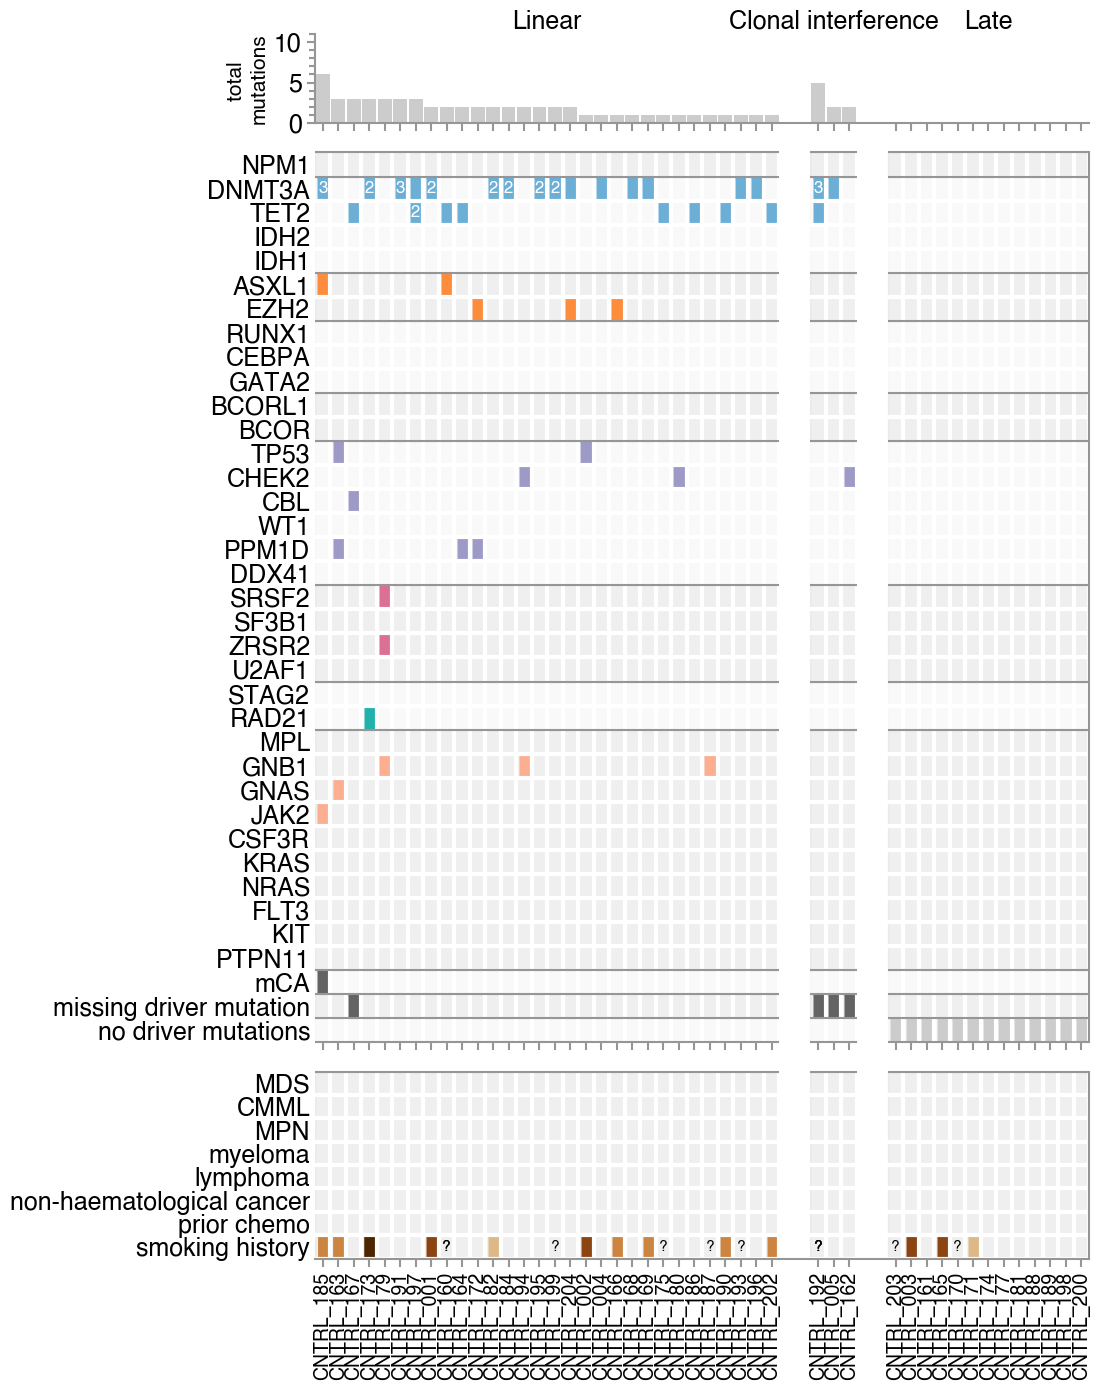

In [ ]:
#plot the figure - controls
# --- layout: numeric x positions with a gap between evolution categories -------
GAP = 2                      # blank slots between categories (same in both panels)
xpos, group_spans, _p = {}, {}, 0
for _evol, _slist in controls_evol_patterns_sorted_mutations.items():
    _start = _p
    for _sn in _slist:
        xpos[_sn[0]] = _p; _p += 1
    if _p > _start:
        group_spans[_evol] = (_start, _p - 1)
    _p += GAP
XMIN, XMAX = -0.5, (max(xpos.values()) + 0.5 if xpos else 0.5)
# -------------------------------------------------------------------------------

COL_IN = 0.173               # inches per sample column - identical in both panels
YLAB_IN = 2.45               # room for the gene labels on the left
fig, axes = plt.subplots(3, 1, figsize = (YLAB_IN + (XMAX - XMIN) * COL_IN, 14), sharex = True, gridspec_kw={'height_ratios': [1, 10, 2.1]})
plt.subplots_adjust(hspace=0.1)


ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]

x = []
y = []
colors = []
annotation = []

x_bar = []
y_bar = []
c_bar = []

helvetica_6 = 18
sample_id_fontsize = 14      # sample IDs on the x axis
qmark_fontsize = 11          # "?" markers for unknown history
axis_lw = 1.5                # same weight as the ax0 (histogram) spines

n = 0
for evol_type, samples_list in controls_evol_patterns_sorted_mutations.items():
#     print(evol_type)
    for sample_numbers in samples_list:
#         print(sample_numbers)
        n+=1
        sample = sample_numbers[0]
        number_genes_mutated = sample_numbers[1]
        number_mutations = sample_numbers[2]
        
        if sample in controls_gene_list.keys():
            sample_genes = controls_gene_list[sample]
        else:
            sample_genes = []
            
        if len(sample_genes)>0: #if the sample has a mutation
            for gene_mutated in sample_genes:
                mutation_ID = panel_list_dict[gene_mutated] #number assigned to the mutation (i.e. its y axis location)
                mutation_class = mutation_classes[gene_mutated]
                mutation_color = mutation_class_colors[mutation_class]
                x.append(sample)
                y.append(mutation_ID)
                colors.append(mutation_color)
                number_of_variants_in_gene = controls_gene_counts[sample][gene_mutated]
                annotation.append(number_of_variants_in_gene)
                

        else: #if the sample doesn't have any mutations
            x.append(sample)
            y.append(panel_list_dict['no mutations'])
            colors.append(grey2)
            annotation.append(0)

        x_bar.append(sample)
        y_bar.append(number_mutations)
        c_bar.append(grey2)
        
#         print(n)

ax0.bar([xpos[s] for s in x_bar], y_bar, width = 0.9, color = c_bar) #histogram at top of plot
ax0.set_ylim(0, 11)
            
verts = list(zip([-2,2,2,-2],[-4,-4,4,4])) #rectangle to plot for each mutation
            
ax1.scatter([xpos[s] for s in x], y, marker = verts, s = 250, color = colors)

for sample, gene, number_variants in zip(x, y, annotation):
    if number_variants>1:
        ax1.annotate(str(number_variants), xy = (xpos[sample], gene), ha = 'center', va = 'center', color = 'white', weight='bold', fontsize = 12)

# Plot other history

# Define 4 brown shades (lightest to darkest)
brown_shades = [(0.87, 0.72, 0.53), (0.80, 0.52, 0.25), (0.55, 0.27, 0.07), (0.30, 0.15, 0.00)]

# Bin pack-years into categories
def get_brown_shade(py):
    if py < 20:
        return brown_shades[0]
    elif py < 100:
        return brown_shades[1]
    elif py < 300:
        return brown_shades[2]
    else:
        return brown_shades[3]

for i in x:
    if i in MDS:
        ax2.scatter(xpos[i], 7, marker = verts, s = 250, color = grey4)
    if i in CMML:
        ax2.scatter(xpos[i], 6, marker = verts, s = 250, color = grey4)
    if i in MPN:
        ax2.scatter(xpos[i], 5, marker = verts, s = 250, color = grey4)
    if i in myeloma:
        ax2.scatter(xpos[i], 4, marker = verts, s = 250, color = grey4)
    if i in lymphoma:
        ax2.scatter(xpos[i], 3, marker = verts, s = 250, color = grey4)
    if i in cancer:
        ax2.scatter(xpos[i], 2, marker = verts, s = 250, color = grey4)
    if i in chemo:
        ax2.scatter(xpos[i], 1, marker = verts, s = 250, color = grey4)
    if i in smoking_dict.keys():
        ax2.scatter(xpos[i], 0, marker = verts, s = 250, color = get_brown_shade(smoking_dict[i]))
    if i in chemo_unknown:   # unknown whether cancer treated with chemo
        ax2.text(xpos[i], 1, '?', ha = 'center', va = 'center', fontsize = qmark_fontsize, color = 'black', weight = 'bold', zorder = 100)
    if i in smoking_unknown:   # unknown smoking history
        ax2.text(xpos[i], 0, '?', ha = 'center', va = 'center', fontsize = qmark_fontsize, color = 'black', weight = 'bold', zorder = 100)

#Configure the plot
            

ax1.set_yticks(list(panel_list_dict.values())) #number assigned to each gene (for y axis)
# display names for the two special rows (internal keys are left unchanged)
_ylabels = ['missing driver mutation' if _g == 'missing driver'
            else 'no driver mutations' if _g == 'no mutations'
            else _g for _g in panel_list_dict.keys()]
ax1.set_yticklabels(_ylabels) #name of the gene

ax1.set_xlim(XMIN, XMAX)
ax1.set_ylim(-0.5, len(panel_list_dict)-0.5)
ax1.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax1.tick_params(axis = 'x', which='major', length=6, width=1.5, color = '#969696')
ax1.tick_params(axis = 'x', which='minor', length=4, width=1.5, color = '#969696')
ax0.set_ylim(0, 11)
ax0.yaxis.set_major_locator(MultipleLocator(5))
ax0.yaxis.set_minor_locator(MultipleLocator(1))
ax0.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax0.set_ylabel('total \nmutations', fontsize = 15)
ax0.tick_params(axis = 'both', which='major', length=6, width=1.5, color = '#969696')
ax0.tick_params(axis = 'both', which='minor', length=4, width=1.5, color = '#969696')
        
ax2.set_xlim(XMIN, XMAX)
ax2.set_ylim(-0.5, 7.5)
ax2.tick_params(labelsize = helvetica_6, axis = 'y', length=0)
ax2.tick_params(axis = 'x', which='major', length=6, width=1.5, color = '#969696', labelcolor='black')
ax2.tick_params(axis = 'x', which='minor', length=4, width=1.5, color = '#969696')


for axis in ['top','right']:
    ax0.spines[axis].set_visible(False)  
    
for axis in ['bottom','left']:
    ax0.spines[axis].set_linewidth(1.5)
    ax0.spines[axis].set_color('#969696')

for axis in ['bottom', 'top', 'left']:
    ax1.spines[axis].set_visible(False)
for axis in ['top', 'left']:
    ax2.spines[axis].set_visible(False)
# controls panel sits to the right of the cases panel, which carries the y axis:
# no left-hand axis line here, a right-hand one instead
for _ax, _sides in [(ax1, ['right']), (ax2, ['right', 'bottom'])]:
    for axis in _sides:
        _ax.spines[axis].set_visible(True)
        _ax.spines[axis].set_linewidth(axis_lw)
        _ax.spines[axis].set_color('#969696')
        # spines default to zorder 2.5, i.e. *under* the white grid lines (zorder 50),
        # which was eating into the axis lines - lift them above everything
        _ax.spines[axis].set_zorder(100)

# --- grid, class shading and dividers, drawn separately for each category -----
# everything is clipped to its category's x-span, so the gaps between categories
# are left completely white (shading, grid lines and dividers all stop at the edge)
linecolor_categories = grey3
_ngenes = len(panel_list_dict)

# class-band boundaries derived from the panel order, so they stay correct if a
# gene is added to or removed from panel_list
_rows = sorted(panel_list_dict.items(), key=lambda kv: kv[1])
_UNSET = object()          # sentinel: 'no mutations' has no class, so None is a real value
_bounds, _prev = [-0.5], _UNSET
for _g, _y in _rows:
    _cl = mutation_classes.get(_g)
    if _prev is not _UNSET and _cl != _prev:
        _bounds.append(_y - 0.5)
    _prev = _cl
_bounds.append(len(_rows) - 0.5)

for _evol, (_a, _b) in group_spans.items():
    _x0, _x1 = _a - 0.5, _b + 0.5

    # alternating shading of the gene-class bands
    # alternation anchored to the TOP band so NPM1 is always the dark one,
    # whatever number of classes the panel ends up with
    _nbands = len(_bounds) - 1
    for _i, (_lo, _hi) in enumerate(zip(_bounds[:-1], _bounds[1:])):
        _dark = ((_nbands - 1 - _i) % 2 == 0)
        ax1.fill_between([_x0, _x1], _lo, _hi, color=grey2, zorder=0,
                         alpha=(0.30 if _dark else 0.10))
    ax2.fill_between([_x0, _x1], -0.5, 7.5, color=grey2, zorder=0, alpha=0.30)

    # white grid: between columns, and between rows
    for _p in range(_a, _b + 1):
        ax1.plot([_p + 0.5, _p + 0.5], [-0.5, _ngenes + 0.5], color='white', lw=3, zorder=50)
        ax2.plot([_p + 0.5, _p + 0.5], [-0.5, 7.5], color='white', lw=3, zorder=50)
    for _j in range(-1, _ngenes):
        if (_j + 0.5) in _bounds:      # a class divider is drawn here instead
            continue
        ax1.plot([_x0, _x1], [_j + 0.5, _j + 0.5], color='white', lw=3, zorder=50)
    for _j in range(-1, 7):
        ax2.plot([_x0, _x1], [_j + 0.5, _j + 0.5], color='white', lw=3, zorder=50)

    # grey rule along the top of the clinical panel (above the MDS row)
    ax2.plot([_x0, _x1], [7.5, 7.5], color=linecolor_categories, lw=axis_lw,
             zorder=60, clip_on=False, solid_capstyle='butt')

    # darker dividers between gene classes (same boundaries as the shading)
    for _y in _bounds:
        ax1.plot([_x0, _x1], [_y, _y], color=linecolor_categories, lw=axis_lw,
                 zorder=60, clip_on=False, solid_capstyle='butt')



ax2.set_yticks([0, 1, 2, 3, 4, 5, 6, 7])
ax2.set_yticklabels(['smoking history', 'prior chemo', 'non-haematological cancer',
                     'lymphoma', 'myeloma', 'MPN', 'CMML', 'MDS'])
        
# ax1.xaxis.set_label_position('top') 

# ax0.set_xticks([])
ax2.xaxis.set_ticks_position('bottom')
# category headings above the histogram
for _evol, (_a, _b) in group_spans.items():
    ax0.text((_a + _b) / 2, ax0.get_ylim()[1], _evol, ha='center', va='bottom',
             fontsize=helvetica_6, weight='bold')
ax2.set_xticks(list(xpos.values()))
ax2.set_xticklabels(list(xpos.keys()), rotation=90, fontsize=sample_id_fontsize,
                    ha='right', va='center', rotation_mode='anchor')

plt.tight_layout()
plt.show()